In [1]:
from typing import Tuple
from symop_proto.envelopes.gaussian_envelope import GaussianEnvelope
from symop_proto.labels.path_label import PathLabel
from symop_proto.labels.polarization_label import PolarizationLabel
from symop_proto.labels.mode_label import ModeLabel
from symop_proto.core.operators import ModeOp
from symop_proto.state.polynomial_state import KetPolyState
from symop_proto.rewrites.linear_mode_unitary import LinearModeUnitary
from symop_proto.rewrites.functions.relabling import rename_path
from symop_proto.algebra.operator_polynomial import OpPoly, OpTerm
import numpy as np

In [2]:
def construct_modes(
    delta_t: float,
    omega1: float,
    omega2: float,
    *,
    sigma: float = 1.0,
) -> Tuple[ModeOp, ModeOp]:
    """
    Build two input modes for the HOM setup, with given carrier frequencies
    omega1, omega2 and relative delay delta_t.

    All units must be consistent (e.g. omega in rad/s, tau in seconds).
    """
    env1 = GaussianEnvelope(omega0=omega1, sigma=sigma, tau=0.0,      phi0=0.0)
    env2 = GaussianEnvelope(omega0=omega2, sigma=sigma, tau=delta_t,  phi0=0.0)

    m1 = ModeOp(env=env1, label=ModeLabel(PathLabel("A"), PolarizationLabel.H()))
    m2 = ModeOp(env=env2, label=ModeLabel(PathLabel("B"), PolarizationLabel.H()))
    return m1, m2

In [3]:
def create_input_state(m1: ModeOp, m2: ModeOp) -> KetPolyState:
    psi_in = KetPolyState.from_creators([m1.create, m2.create])
    return psi_in

## Beam Splitter Logic

Because the framework does not yet implement the device abstractions, we carry out the operation manually here.

In [4]:
def apply_beam_splitter_full(
    psi_in: KetPolyState,
    m1: ModeOp,
    m2: ModeOp,
    *,
    in_path1: str = "A",
    in_path2: str = "B",
    internal_path1: str = "BS1",
    internal_path2: str = "BS2",
    out_path1: str = "C",
    out_path2: str = "D",
) -> Tuple[KetPolyState, Tuple[ModeOp, ModeOp, ModeOp, ModeOp]]:
    """
    One-shot HOM beam splitter:

      1) rename input paths in psi_in: in_path1, in_path2 -> internal_path1, internal_path2
      2) read the *actual* internal modes from psi_internal.unique_modes
      3) build a 4-mode 50/50 BS on those internal modes (block-diagonal in temporal mode)
      4) apply BS
      5) rename internal_path1/2 -> out_path1/2
      6) return psi_out and the four output modes (C_env1, D_env1, C_env2, D_env2)
    """

    # --- 1) rename input paths -> internal in the STATE ----------------------
    psi_internal = rename_path(psi_in, in_path1, internal_path1)
    psi_internal = rename_path(psi_internal, in_path2, internal_path2)

    # --- 2) get the actual internal modes from the state ---------------------
    # Expect exactly two: one on internal_path1 with env1, one on internal_path2 with env2
    internal_modes = psi_internal.unique_modes  # Tuple[ModeOp, ModeOp, ...]
    modes_by_path = {
        m.label.path.name: m
        for m in internal_modes
        if isinstance(m.label, ModeLabel)
    }

    try:
        mode_1_int = modes_by_path[internal_path1]  # env1, path BS1
        mode_2_int = modes_by_path[internal_path2]  # env2, path BS2
    except KeyError:
        raise RuntimeError(
            f"After renaming, state does not contain both internal paths "
            f"{internal_path1!r}, {internal_path2!r}; got {list(modes_by_path)}"
        )

    # env/pol taken from the modes actually in the state
    env1, pol1 = mode_1_int.env, mode_1_int.label.pol
    env2, pol2 = mode_2_int.env, mode_2_int.label.pol

    # --- 3) build 4 internal modes: 2 existing + 2 new cross-path modes ------
    # existing ones (these MUST be used so LinearModeUnitary recognizes them)
    A1_int = mode_1_int                                # env1 on BS1
    B2_int = mode_2_int                                # env2 on BS2

    # new ones (crossed paths)
    B1_int = ModeOp(env=env1, label=ModeLabel(PathLabel(internal_path2), pol1))  # env1 on BS2
    A2_int = ModeOp(env=env2, label=ModeLabel(PathLabel(internal_path1), pol2))  # env2 on BS1

    # 50/50 BS, block-diagonal in temporal mode
    c = s = 1 / np.sqrt(2)
    # basis ordering: (A1_int, B1_int, A2_int, B2_int)
    U = np.array(
        [
            [c,  s, 0, 0],   # A1_out <= A1,B1   (env1 block)
            [-s, c, 0, 0],   # B1_out
            [0,  0, c, s],   # A2_out <= A2,B2   (env2 block)
            [0,  0,-s, c],   # B2_out
        ],
        dtype=complex,
    )

    BS_internal = LinearModeUnitary((A1_int, B1_int, A2_int, B2_int), U)

    # --- 4) apply BS to the internal state -----------------------------------
    psi_after_bs_int = BS_internal.on_state(psi_internal)

    # --- 5) rename internal paths -> output paths in the STATE ---------------
    psi_out = rename_path(psi_after_bs_int, internal_path1, out_path1)
    psi_out = rename_path(psi_out, internal_path2, out_path2)

    # --- 6) build output modes for coincidence operators ---------------------
    C_env1 = ModeOp(env=env1, label=ModeLabel(PathLabel(out_path1), pol1))
    D_env1 = ModeOp(env=env1, label=ModeLabel(PathLabel(out_path2), pol1))
    C_env2 = ModeOp(env=env2, label=ModeLabel(PathLabel(out_path1), pol2))
    D_env2 = ModeOp(env=env2, label=ModeLabel(PathLabel(out_path2), pol2))

    return psi_out, (C_env1, D_env1, C_env2, D_env2)


In [5]:
def number_operator_for_modes(*modes: ModeOp) -> OpPoly:
    terms = []
    for m in modes:
        terms.append(OpTerm(coeff=1.0, ops=(m.create, m.ann)))
    return OpPoly(tuple(terms))
def coincidence_operator(C1: ModeOp, D1: ModeOp, C2: ModeOp, D2: ModeOp) -> OpPoly:
    N_C = number_operator_for_modes(C1, C2)
    N_D = number_operator_for_modes(D1, D2)
    return N_C * N_D


## Compute the coincidence (single shot)

We constrcut the function, which creates the modes and the output state of the beamsplitter, then the expectation value for the coincidence is computed for this setup.

In [6]:
def hom_coincidence_probability(
    delta_t: float,
    omega1: float,
    omega2: float,
    *,
    sigma: float = 1.0,
) -> float:
    # 1) build modes + input state
    m1, m2 = construct_modes(delta_t, omega1, omega2, sigma=sigma)
    psi_in = create_input_state(m1, m2)

    # 2) beam splitter + output modes on C/D
    psi_out, (C1, D1, C2, D2) = apply_beam_splitter_full(
        psi_in,
        m1,
        m2,
        in_path1="A",
        in_path2="B",
        internal_path1="BS1",
        internal_path2="BS2",
        out_path1="C",
        out_path2="D",
    )

    # 3) coincidence operator
    C_op = coincidence_operator(C1, D1, C2, D2)

    # 4) expectation value
    P = psi_out.expect(C_op)   # complex, but imag ~ 0
    return float(P.real)

## Carry out the simulation

1.6560509554140127e-14


Δω sweep:   0%|          | 0/101 [00:00<?, ?it/s]

Δt sweep:   0%|          | 0/101 [00:00<?, ?it/s]

Δt sweep:   0%|          | 0/101 [00:00<?, ?it/s]

Δt sweep:   0%|          | 0/101 [00:00<?, ?it/s]

...

Δt sweep:   0%|          | 0/101 [00:00<?, ?it/s]

Δt sweep:   0%|          | 0/101 [00:00<?, ?it/s]

Δt sweep:   0%|          | 0/101 [00:00<?, ?it/s]

Δt sweep:   0%|          | 0/101 [00:00<?, ?it/s]

Δt sweep:   0%|          | 0/101 [00:00<?, ?it/s]

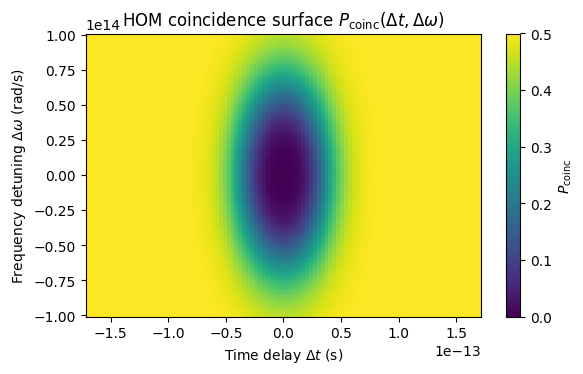

In [20]:
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# delay range ~ experimental ±50 µm
t_min, t_max = -1.7e-13, 1.7e-13   # seconds, ≈ [-50, +50] µm / c
N_t = 101
delta_ts = np.linspace(t_min, t_max, N_t)

# spectral detuning range: centered at 0, scale set by Δω from the paper
omega0=0

domega_min, domega_max = -1e14, 1e14
N_w = 101
delta_omegas = np.linspace(domega_min, domega_max, N_w)

# choose temporal width so that FWHM ≈ 4e-14 s
# for a Gaussian exp(-t^2 / (2 σ_t^2)), FWHM = 2√(2 ln 2) σ_t ≈ 2.355 σ_t
# σ_t ≈ δτ_FWHM / 2.355
delta_tau_FWHM = 3.9e-14        # target from experiment
sigma_t = delta_tau_FWHM / 2.355
print(sigma_t)  # ≈ 1.7e-14 s

sigma = 1.7e-14  # seconds

P = np.empty((N_w, N_t), dtype=float)

for i, domega in enumerate(tqdm(delta_omegas, desc="Δω sweep")):
    omega1 = omega0
    omega2 = omega0 + domega
    for j, dt in enumerate(tqdm(delta_ts, desc="Δt sweep", leave=False)):
        P[i, j] = hom_coincidence_probability(dt, omega1, omega2, sigma=sigma)

## Plotting
We are ready to plot the coincidence dependence on the temporal and frequential missmatch between the incomming photons.

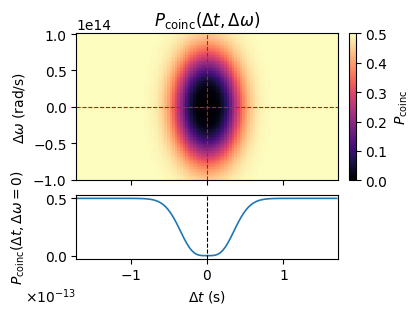

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter, NullFormatter

# assume delta_ts, delta_omegas, P already computed
idx_w0 = np.argmin(np.abs(delta_omegas))
P_vs_t = P[idx_w0, :]
T, DW = np.meshgrid(delta_ts, delta_omegas)

fig = plt.figure(figsize=(5, 3), constrained_layout=True)
gs = GridSpec(2, 1, height_ratios=[2.8, 1.2], figure=fig)

ax_main = fig.add_subplot(gs[0, 0])
ax_t    = fig.add_subplot(gs[1, 0], sharex=ax_main)

# --- main colormap ---
pcm = ax_main.pcolormesh(T, DW, P, shading="auto", cmap="magma")
ax_main.set_ylabel(r"$\Delta \omega$ (rad/s)")
ax_main.set_title(r"$P_\mathrm{coinc}(\Delta t,\Delta \omega)$")

ax_main.axhline(0.0, color="r", ls="--", lw=0.8)
ax_main.axvline(0.0, color="r", ls="--", lw=0.8)

ax_main.tick_params(axis="x", labelbottom=False)
ax_main.xaxis.set_major_formatter(NullFormatter())
ax_main.xaxis.offsetText.set_visible(False)

cbar = fig.colorbar(pcm, ax=ax_main, fraction=0.047, pad=0.04)
cbar.set_label(r"$P_\mathrm{coinc}$")

ax_t.plot(delta_ts, P_vs_t, "-", lw=1.2)
ax_t.axvline(0.0, color="k", ls="--", lw=0.8)

ax_t.set_xlabel(r"$\Delta t$ (s)")
ax_t.set_ylabel(r"$P_\mathrm{coinc}(\Delta t, \Delta \omega=0)$")

# scientific notation only on bottom
fmt = ScalarFormatter(useMathText=True)
fmt.set_powerlimits((-2, 2))
ax_t.xaxis.set_major_formatter(fmt)

offset = ax_t.xaxis.get_offset_text()
offset.set_x(0.0)
offset.set_y(-0.12)


fig.align_xlabels([ax_main, ax_t])
fig.align_ylabels([ax_main, ax_t])
fig.set_constrained_layout_pads(w_pad=0.5, h_pad=0.02)

plt.show()
fig.savefig("hom_coincidence.pdf", dpi=600, bbox_inches="tight")

